# Challenge Sesión 4: Explorando embeddings con Autoencoders

Hola y bienvenidos al challenge de la sesión 4!

En la sesión de hoy vamos a emplear los autoencoders para explorar representaciones vectoriales de imágenes y entender mejor cómo aprenden los modelos de redes neuronales profundas. Y lo mejor de todo es que, empleando este tipo de modelos autosupervisados, ¡no vamos a necesitar ningún tipo de dato etiquetado!

Asegúrate de tener activa la GPU al entrenar y lee todo con atención : )


Acknowledgements: Vikram Tiwari

Antes de comenzar, y para ayudar a evaluar vuestros notebooks, por favor rellenad aquí vuestros datos:

**Equipo**: ...

**Nombres**:
- ...

In [1]:
import tensorflow as tf
import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

## Datos

Vamos a emplear el que sea quizás el dataset de imágenes más conocido, [MNIST](https://en.wikipedia.org/wiki/MNIST_database).

Se trata de un conjunto de imágenes de 28x28 píxeles en blanco y negro de dígitos escritos a mano, que se suele emplear como dataset didáctico para clasificación de imágenes.

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')

X_train = X_train.astype('float32') / 255.
X_test =X_test.astype('float32') / 255.

print(f"{X_train.shape=}")
print(f"{X_test.shape=}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train.shape=(60000, 28, 28)
X_test.shape=(10000, 28, 28)


## Autoencoders clásicos de ejemplo

Para calentar, crearemos un autoencoder simple, con dos capas densas, una para el encoder y otra par el decoder.

In [3]:
# Definimos la dimensión de entrada, que es el resultado de aplanar nuestra imagen de 28x28
INPUT_DIM = 784

# Fijamos la dimensión del vector de representación embebida
ENCODING_DIM = 64 # A vuestra elección, pero un número relativamente bajo. Podéis probar varios a ver cómo cambia

# Siguiendo la convención de Keras, creamos un placeholder del Input
input_img = layers.Input(shape=(INPUT_DIM,))

# Definimos la capa densa que forma el encoder con activaciones relu
encoded = layers.Dense(ENCODING_DIM, activation='relu')(input_img)

# Definimos la siguiente capa densa, que forma al decoder. Como es la última capa, su activación tiene que ser una que esté en el rango 0 a 1
decoded = layers.Dense(INPUT_DIM, activation='sigmoid')(encoded)

# Finalmente, definimos la secuencia como un modelo
autoencoder = tf.keras.models.Model(input_img, decoded)

Usando estos mismos objetos de Python ya definidos podemos crear modelos parciales para representar el encoder y el decoder.

In [4]:
# Podemos definir un modelo de keras que represente únicamente al encoder para poder usarlo por separado
autoencoder = tf.keras.models.Model(input_img, decoded)
encoder = tf.keras.models.Model(input_img, encoded)

# Decoder
# Aquí necesitaremos definir un nuevo Input con la dimensión del embedding
encoded_input = tf.keras.layers.Input(shape=(ENCODING_DIM,))
decoder_layer = autoencoder.layers[-1]
decoder = tf.keras.models.Model(encoded_input, decoder_layer(encoded_input))

Ahora simplemente entrenamos el modelo. Notad que no estamos empleando `y_train` ni `y_test` para ello, ya que tratamos que el output devuelva lo mismo que el input, y por tanto no nos hacen falta etiquetas. El error es simplemente la diferencia entre los píxeles a la entrada y los logrados a la salida.

In [5]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001) # Cualquier optimizador estándar nos debería valer, ajustando bien la learning rate iterativamente si no acertamos al principio
autoencoder.compile(
    optimizer=opt,
    loss= 'binary_crossentropy' # necesitamos una función de pérdida que permita comparar los píxeles de la imagen de entrada con la imagen reconstruida a la salida
)

In [6]:
X_train.shape
type(X_train)
print(INPUT_DIM)

784


In [7]:
# Ya que estamos empleando Dense, tenemos que aplanar los datos bidimensionales de las imágenes
X_train_flat = X_train.reshape(len(X_train), INPUT_DIM) # recuerda que esto son arrays de numpy, así que puedes usar el método .reshape(...)
X_test_flat = X_test.reshape(len(X_test), INPUT_DIM)

In [8]:
# Entrenamos el modelo
num_epochs = 10 # con unos poquitos debería bastar
batch_size = 256

autoencoder.fit(
    x=X_train_flat,
    y=X_train_flat,
    epochs=num_epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)  # podríamos haber dividido en un validation set. Podéis hacerlo para puntos extra!
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3485 - val_loss: 0.1634
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1527 - val_loss: 0.1257
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1223 - val_loss: 0.1083
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1065 - val_loss: 0.0978
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0971 - val_loss: 0.0906
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0904 - val_loss: 0.0856
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0855 - val_loss: 0.0819
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0821 - val_loss: 0.0794
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0797 - val_loss: 0.0777
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0780 - val_loss: 0.0765


Una vez satisfechos con el entrenamiento, vamos a aplicar el modelo sobre el conjunto de test para ver qué imágenes genera.

In [9]:
encoded_imgs = encoder.predict(X_test_flat)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


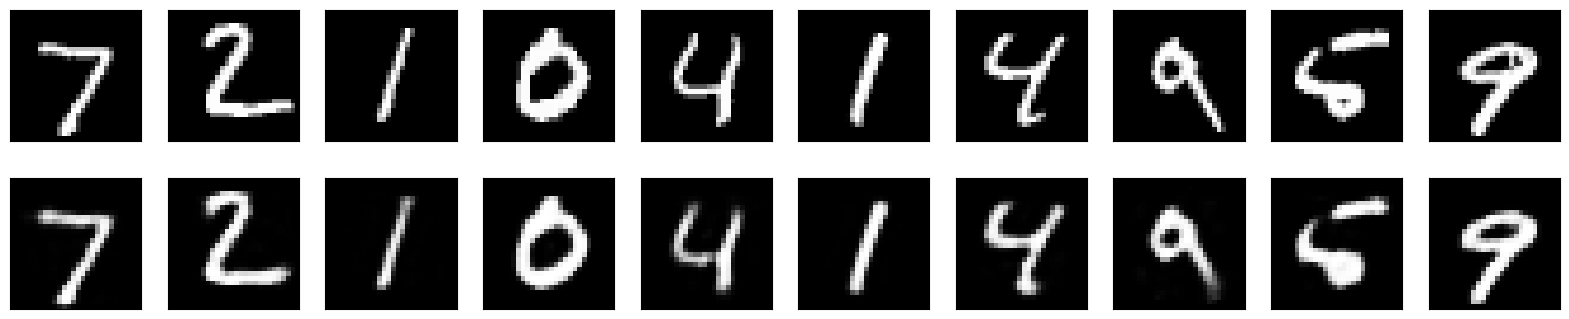

In [10]:
def plot_comparison(flat_original: np.ndarray, flat_reconstruction: np.ndarray, num_images: int = 10) -> None:
    plt.figure(figsize=(20, 4))
    for i in range(num_images):
        # Imagen original
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(flat_original[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Imagen reconstruida
        ax = plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(flat_reconstruction[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

plot_comparison(X_test_flat, decoded_imgs)

Ahora que tenemos clara la estructura general, es fácil añadir complejidad al modelo. Por ejemplo, podemos poner múltiples capas densas para el encoder y decoder, en lugar de solo una.

In [18]:
input_img = tf.keras.layers.Input(shape=(INPUT_DIM,))

# Encoder
x = layers.Dense(128, activation='relu')(input_img)
x = layers.Dense(64, activation='relu')(x)
encoded = layers.Dense(32, activation='relu')(x)

# Decoder
x = layers.Dense(64, activation='relu')(encoded)
x = layers.Dense(128, activation='relu')(x)
decoded = layers.Dense(INPUT_DIM, activation='sigmoid')(x)  # <-- CLAVE (784)

autoencoder_multilayer = tf.keras.models.Model(input_img, decoded)

opt = tf.keras.optimizers.Adam(learning_rate=0.001)
autoencoder_multilayer.compile(optimizer=opt, loss='binary_crossentropy')

In [19]:
autoencoder_multilayer.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
num_epochs = 12
batch_size = 256

autoencoder_multilayer.fit(
    x=X_train_flat,
    y=X_train_flat,
    epochs=num_epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.3393 - val_loss: 0.1675
Epoch 2/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1579 - val_loss: 0.1361
Epoch 3/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1338 - val_loss: 0.1223
Epoch 4/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1223 - val_loss: 0.1163
Epoch 5/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1166 - val_loss: 0.1124
Epoch 6/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1124 - val_loss: 0.1082
Epoch 7/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1084 - val_loss: 0.1050
Epoch 8/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1053 - val_loss: 0.1030
Epoch 9/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1031 - val_loss: 0.1007
Epoch 10/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1012 - val_loss: 0.0992
Epoch 11/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0997 - val_loss: 0.0982
Epoch 12/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

In [ ]:
decoded_imgs = autoencoder_multilayer.predict(X_test_flat)
plot_comparison(X_test_flat, decoded_imgs)

In [21]:
# Compruebo shapes antes de entrenar
autoencoder_multilayer.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,154 (2.54 MB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,770 (1.70 MB)

También podemos emplear las técinas que hemos aprendido en clasificación de imágenes y detección de objetos, en las que hemos visto que las redes convolucionales son un elemento práctico para el aprendizaje de características relevantes en imágenes.

In [24]:
input_img = tf.keras.layers.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)     # la última capa del encoder debería ser un pooling

# Tened en cuenta que dependiendo de las transformaciones definidas, tendremos un espacio embebido de diferente tamaño a los anteriores. ¿Sabéis indicar a qué tamaño habéis llegado?

x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)      # Usamos capas de upsampling para volver a la dimensión original progresivamente
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)                           # 16x16x64
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)                           # 32x32x32
x = tf.keras.layers.Cropping2D(((2, 2), (2, 2)))(x)           # Volvemos a 28x28 (recortamos 2 píxeles por lado)
decoded = tf.keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)


autoencoder = tf.keras.models.Model(input_img, decoded)
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
autoencoder.compile(
    optimizer=opt,
    loss='binary_crossentropy'
)

# Una cosa interesante es que, si usamos la misma función de pérdida, la pérdida que calculamos sigue siendo directamente comparable a la de antes!
autoencoder.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │         4,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 64)       │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_1 (Cropping2D)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,441 (185.32 KB)

 Trainable params: 47,441 (185.32 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
X_train_2d = X_train[..., np.newaxis] # necesitaremos ahora que los inputs tengan shape (len(X), 28, 28, 1)
X_test_2d = X_test[..., np.newaxis]
print(X_train_2d.shape)
print(X_test_2d.shape)
print(X_train_2d.min(), X_train_2d.max())

(60000, 28, 28, 1)
(10000, 28, 28, 1)
0.0 1.0


In [29]:
num_epochs = 10
batch_size = 256

autoencoder.fit(
    x=X_train_2d,
    y=X_train_2d,
    epochs=num_epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test_2d, X_test_2d)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.3071 - val_loss: 0.1348
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1304 - val_loss: 0.1156
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1149 - val_loss: 0.1070
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1070 - val_loss: 0.1019
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1025 - val_loss: 0.0985
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0989 - val_loss: 0.0960
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0965 - val_loss: 0.0938
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0949 - val_loss: 0.0922
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0936 - val_loss: 0.0920
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0922 - val_loss: 0.0898


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


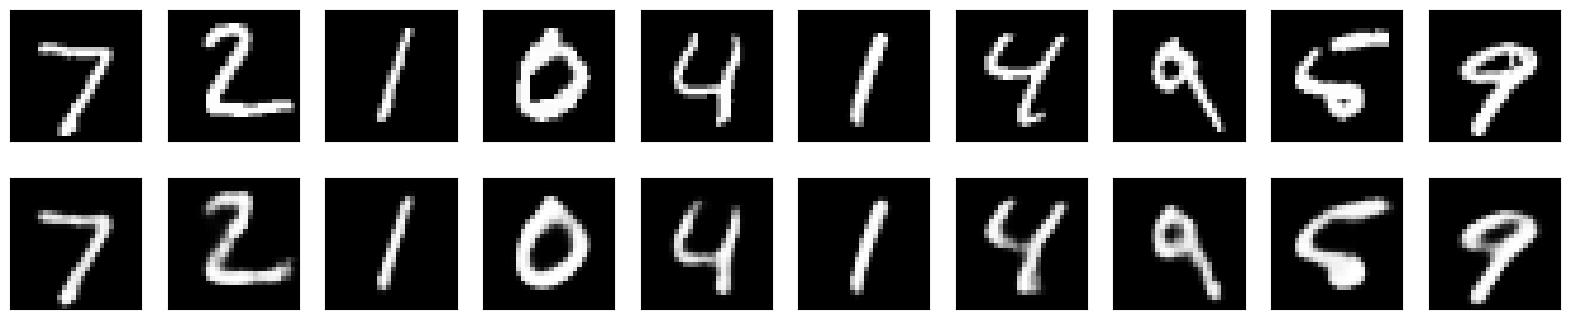

In [30]:
decoded_imgs = autoencoder.predict(X_test_2d)
plot_comparison(X_test_flat, decoded_imgs.reshape(-1, 28, 28))

Puede ser curioso echarle un vistazo a las representaciones que se ha generado el modelo! Como hemos empleado convoluciones, que tienen múltiples filtros, la representación es tridimensional. Necesitaremos aplanar una de las dimensiones para visualizar en pantalla.

In [31]:
encoder = tf.keras.models.Model(input_img, encoded)
encoded_imgs = encoder.predict(X_test_2d)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [32]:
encoded_imgs.shape

(10000, 4, 4, 8)

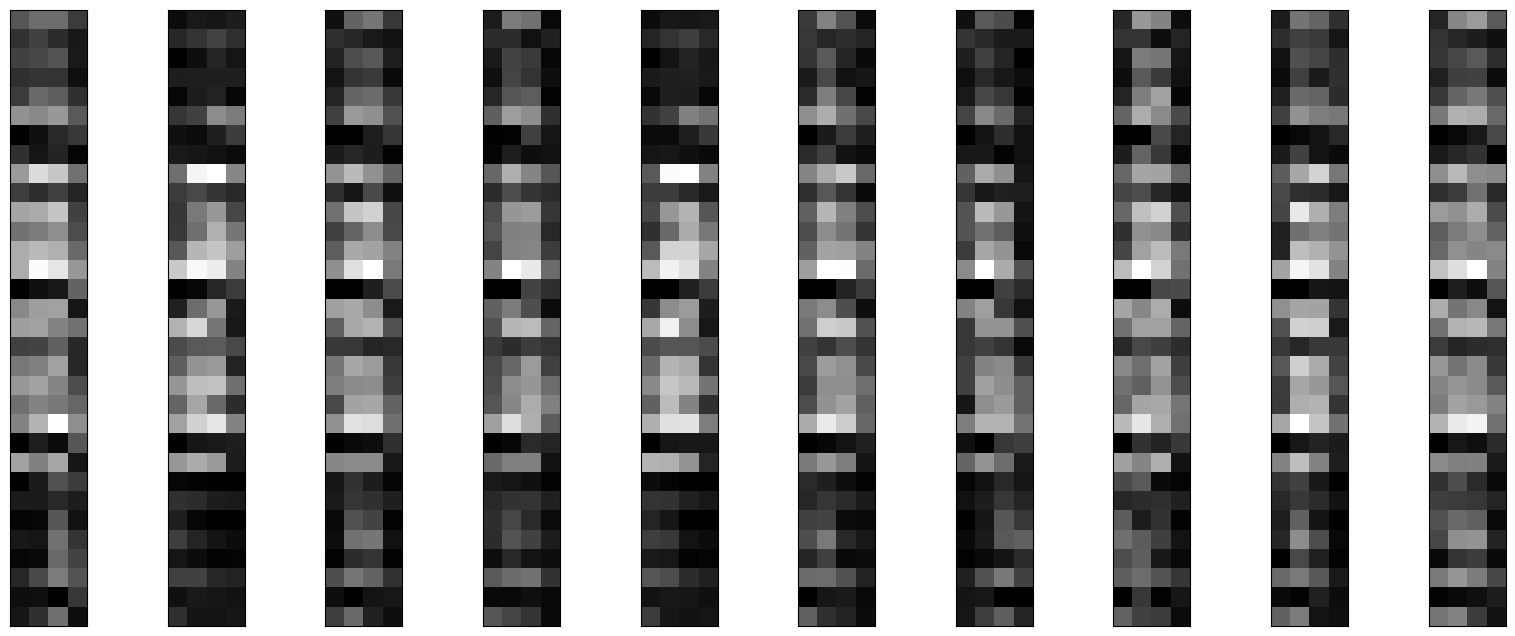

In [33]:
num_images = 10
plt.figure(figsize=(20, 8))
for i in range(num_images):
    ax = plt.subplot(1, num_images, i + 1)
    plt.imshow(encoded_imgs[i + 1].reshape(4, 4 * 8).T)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## Variational Autoencoder (VAE)

Vamos ya a por la chicha.

Un VAE añade restricciones a las representaciones codificadas que aprende, tal que puede recuperar un modelo de la variable latente para sus datos de entrada. En vez de aprender una función arbitraria en la codificación, aprende los parámetros de una distribución de probabilidades que representa tus datos.

Si sacamos muestras de esta distribución aprendida, podemos recuperar a través del decoder nuevas muestras del set de datos de entrada!

Para aplicar esta restricción adicional, necesitaremos una función de pérdida adicional además de la función de pérdida de reconstrucción que ya empleábamos. Esta actuará como término regularizador de la distribución que queremos aprender.

Para esta segunda función de pérdida, usaremos [KL loss](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence).

In [34]:
original_dim = INPUT_DIM
input_shape = (original_dim, )
intermediate_dim = 512
batch_size = 256
latent_dim = 2  # Usaremos tan solo 2 de dimensión latente para poder representar en el plano el espacio latente
epochs = 30

In [35]:
# Encoder

# Creamos primero una capa densa que transforme a una dimensión intermedia
inputs = keras.Input(shape=input_shape, name="encoder_input")
x = layers.Dense(intermediate_dim, activation="relu")(inputs)
# Después, transformamos esto a DOS variables latentes diferentes, cada una con su capa densa distinta
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Y para continuar, samplearemos de la distribución gausiana que definen estas dos variables!
# En Keras 3, creamos una capa personalizada en lugar de usar Lambda + tf.keras.backend
class Sampling(keras.layers.Layer):
    """Samplea z de la distribución N(z_mean, exp(z_log_var))."""
    def call(self, z_mean, z_log_var):
        # leed bien este código para entender cómo funciona el sampleo
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean))
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

# Integramos el sampleo dentro del propio modelo!
z = Sampling(name='z')(z_mean, z_log_var)

encoder = tf.keras.models.Model(inputs, [z_mean, z_log_var, z], name='encoder')

# Vamos a visualizarlo para ver que lo tenemos claro
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 512)       │    401,920 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │      1,026 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │      1,026 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 403,972 (1.54 MB)

 Trainable params: 403,972 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

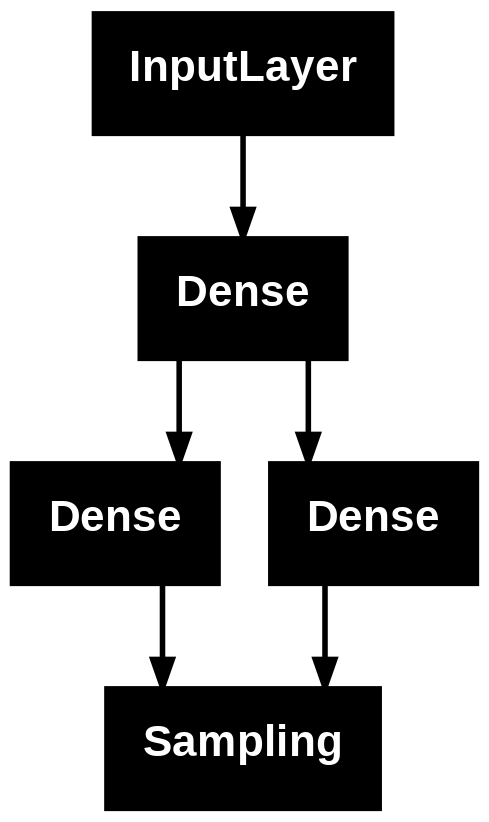

In [36]:
tf.keras.utils.plot_model(encoder)

In [37]:
# Decoder
latent_inputs = tf.keras.layers.Input(shape=(latent_dim,), name="z_sampling")
x = layers.Dense(intermediate_dim, activation="relu")(latent_inputs)  # Una capa densa para volver a la dimensión intermedia
outputs = layers.Dense(original_dim, activation="sigmoid")(x)  # Y otra más para volver a la dimensión del input

decoder = tf.keras.models.Model(latent_inputs, outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,728 (1.54 MB)

 Trainable params: 403,728 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

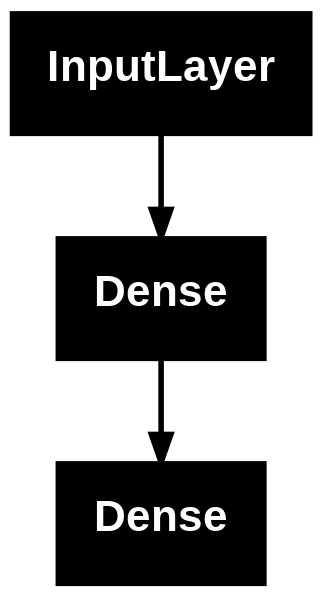

In [38]:
tf.keras.utils.plot_model(decoder)

In [42]:
# Y ahora el VAE completo
# En Keras 3, model.add_loss() no está soportado en modelos funcionales.
# En su lugar, usamos una capa personalizada que calcula la KL loss y la añade al modelo.
# La reconstruction loss irá directamente en compile(loss=...).
class KLLoss(keras.layers.Layer):
    """Calcula la KL divergence y la añade como loss, pasando z sin modificar."""
    def call(self, z, z_mean, z_log_var):
        # La fórmula de la KL divergence para una gausiana respecto a N(0,1):
        # KL = -0.5 * mean_batch(sum_dims(1 + log_var - mean^2 - exp(log_var)))
        # Pista: usad keras.ops.square, keras.ops.exp, keras.ops.sum y keras.ops.mean
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var),
                axis=-1)  # completad la fórmula dentro del sum
        )
        self.add_loss(kl_loss)
        return z  # pasamos z sin modificar para mantener la capa en el camino del grafo

# Desempaquetamos las tres salidas del encoder
z_mean, z_log_var, z = encoder(inputs)
z = KLLoss()(z, z_mean, z_log_var)  # KLLoss queda en el camino principal del grafo
outputs = decoder(z)

models = (encoder, decoder)
vae = tf.keras.models.Model(inputs, outputs, name="vae")  # Definimos el modelo funcional de inputs a outputs
def reconstruction_loss(y_true, y_pred):
    return keras.ops.mean(
        keras.losses.binary_crossentropy(y_true, y_pred) * original_dim
    )
# La reconstruction loss va en compile(); la KL loss se añade vía la capa KLLoss
vae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=reconstruction_loss  # Pista: usad keras.losses.binary_crossentropy(y_true, y_pred) * original_dim
)
vae.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 2),       │    403,972 │ encoder_input[0]… │
│ (Functional)        │ (None, 2), (None, │            │                   │
│                     │ 2)]               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kl_loss_3 (KLLoss)  │ (None, 2)         │          0 │ encoder[3][2],    │
│                     │                   │            │ encoder[3][0],    │
│                     │                   │            │ encoder[3][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 784)       │    403,728 │ kl_loss_3[0][0]   │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 807,700 (3.08 MB)

 Trainable params: 807,700 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

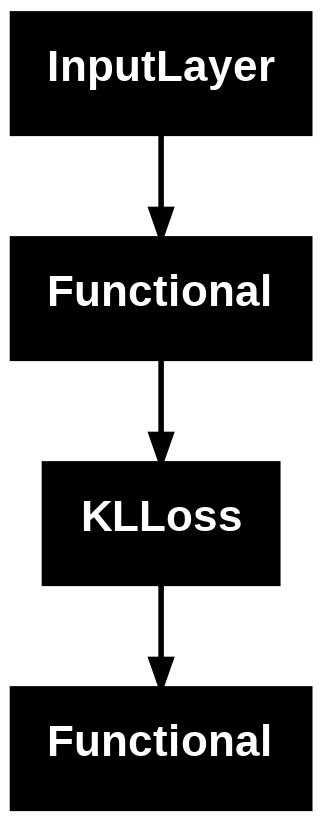

In [43]:
tf.keras.utils.plot_model(vae)

In [46]:
# En Keras 3, pasamos X_train_flat como input Y como target,
# ya que la reconstruction loss se calcula en compile(loss=...)
vae.fit(
    X_train_flat,
    X_train_flat,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_flat, X_test_flat),
    callbacks=[
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "vae_mnist_best.h5",
        monitor="val_loss",
        save_best_only=True
    )
] # se os ocurre algún callback que sería interesante tener aquí?
)
# guarda el resultado de este modelo en h5 para poder volverlo a cargar si se nos desconecta el entorno
vae.save("vae_mnist_final.keras")

Epoch 1/30
223/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 150.2791

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 150.2790 - val_loss: 152.2798
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 150.0502 - val_loss: 152.4543
Epoch 3/30
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 150.1541

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 150.1517 - val_loss: 152.2296
Epoch 4/30
223/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 149.5936

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 149.6049 - val_loss: 152.0287
Epoch 5/30
229/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 149.9660

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 149.9560 - val_loss: 151.9667
Epoch 6/30
225/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 149.6738

...

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 147.5958 - val_loss: 150.9394
Epoch 22/30
230/235 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 147.3098

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 147.3162 - val_loss: 150.8813
Epoch 23/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 147.4332 - val_loss: 150.8945
Epoch 24/30
229/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 147.3378

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 147.3378 - val_loss: 150.8199
Epoch 25/30
231/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 147.5781

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 147.5707 - val_loss: 150.6778
Epoch 26/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 146.8850 - val_loss: 150.7838
Epoch 27/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 146.9387 - val_loss: 150.9520
Epoch 28/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 147.0905 - val_loss: 150.6922
Epoch 29/30
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 146.7558

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 146.7579 - val_loss: 150.6571
Epoch 30/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 146.6492 - val_loss: 150.7779


Ahora podemos coger el espacio latente del VAE y sacar muestras de él para general nuevos dígitos! Así también examinaremos el aspecto de este espacio latente.

Lo hemos creado de solo dos dimensiones a propósito para poder sacar muestras en dos dimensiones y poder visualizarlo en pantalla.

In [47]:
Z_mean, _, _ = encoder.predict(X_test_flat, batch_size=batch_size)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Figure size 640x480 with 0 Axes>

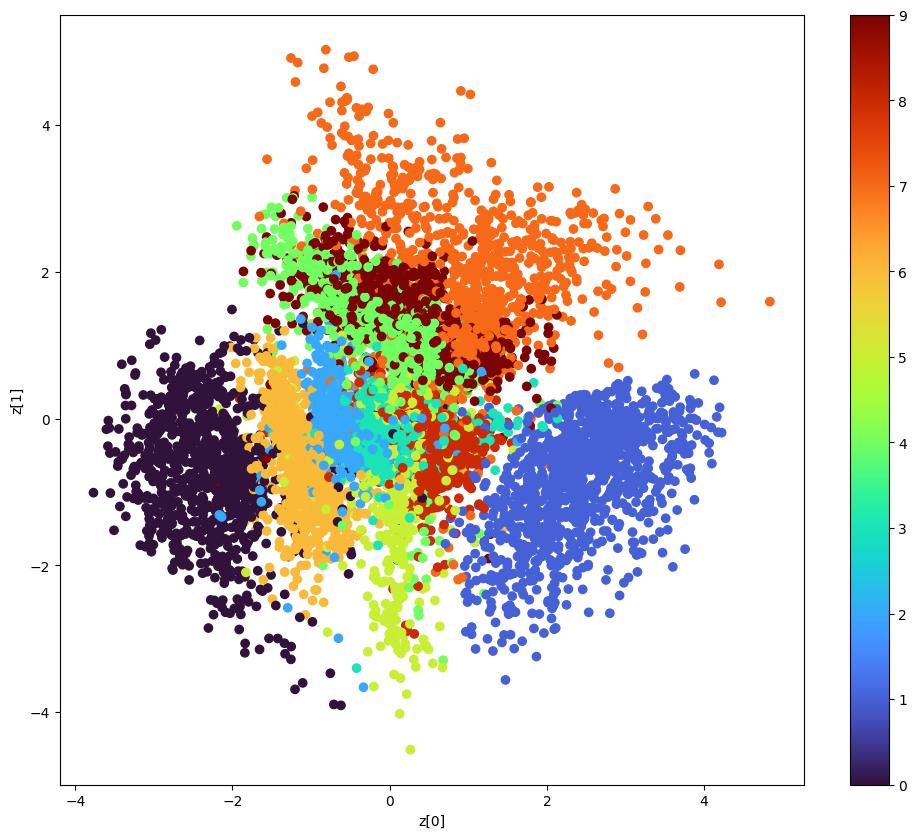

In [48]:
# Primero, representamos dónde se situan las muestras del set de test en el espacio latente, coloreando cada dígito de un color diferente para ver cómo se agrupan

Z_mean, _, _ = encoder.predict(X_test_flat, batch_size=batch_size)
plt.set_cmap('turbo')
plt.figure(figsize=(12, 10))
plt.scatter(Z_mean[:, 0], Z_mean[:, 1], c=y_test)
plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


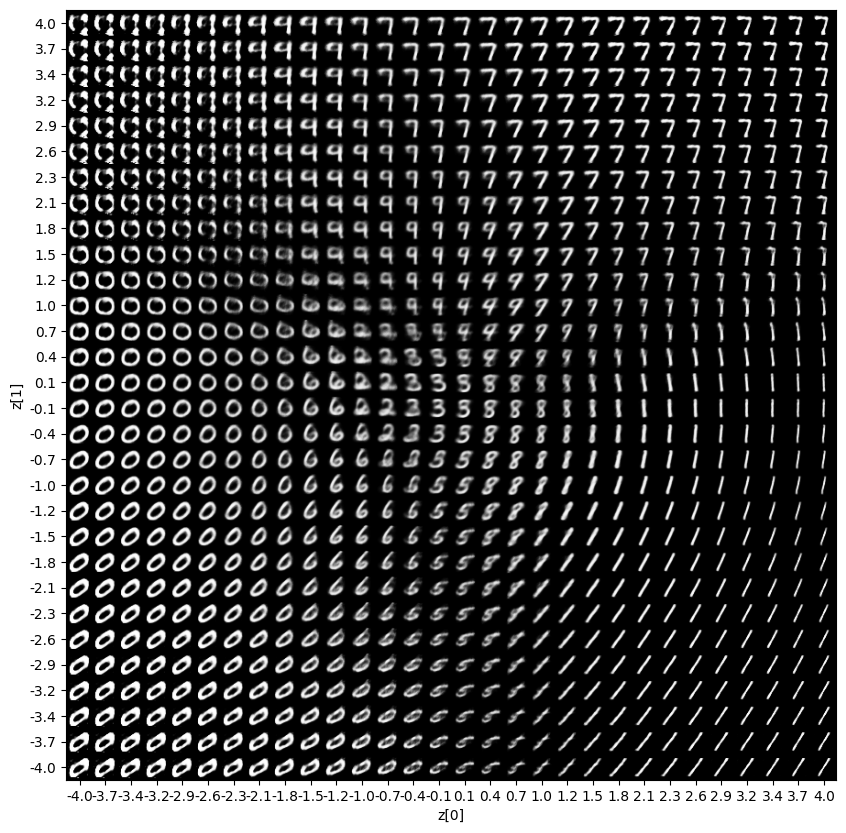

In [49]:
# Dejo este código hecho para que podamos comparar todos el mismo tipo de imágenes de nuestros distintos modelos
# pero sentíos libres de copiarlo y modificarlo en otra celda o añadir más representaciones interesantes! Puntos extra!

n = 30
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = np.linspace(-4, 4, n)
grid_y = np.linspace(-4, 4, n)[::-1]

samples = []

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        samples.append(((i, j), z_sample))

z_samples = np.array([s[1] for s in samples]).reshape(-1, 2)
decoded_images = decoder.predict(z_samples)
pos_to_image = {
    coords: decoded_images[k] for k, (coords, zs) in enumerate(samples)
}

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        decoded_image = pos_to_image[(i, j)]
        digit = decoded_image.reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size, j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
start_range = digit_size // 2
end_range = n * digit_size + start_range - 1
pixel_range = np.arange(start_range, end_range, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.imshow(figure, cmap='Greys_r')
plt.show()

In [50]:
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np

# Define the model function
def plot_sample(z0: float, z1: float):
    img = decoder.predict(np.array([[z0, z1]]), verbose=0)
    plt.imshow(img.reshape(digit_size, digit_size))
    plt.gray()
    plt.gca().get_xaxis().set_visible(False)
    plt.gca().get_yaxis().set_visible(False)
    plt.show()

# Create sliders and link them to the model function
interact(plot_sample, z0=(-4.0, 4, 0.1), z1=(-4.0, 4, 0.1))

interactive(children=(FloatSlider(value=0.0, description='z0', max=4.0, min=-4.0), FloatSlider(value=0.0, desc…

<function __main__.plot_sample(z0: float, z1: float)>

# Extra: hacer que un número se transforme ligeramente en otro

In [56]:
import numpy as np
import matplotlib.pyplot as plt

idx1 = 0
idx2 = 1

img1 = X_test_flat[idx1:idx1+1]
img2 = X_test_flat[idx2:idx2+1]

In [52]:
z_mean1, _, _ = encoder.predict(img1)
z_mean2, _, _ = encoder.predict(img2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [53]:
n_steps = 15
z_interp = []

for alpha in np.linspace(0, 1, n_steps):
    z = (1 - alpha) * z_mean1 + alpha * z_mean2
    z_interp.append(z)

z_interp = np.vstack(z_interp)

In [54]:
generated = decoder.predict(z_interp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


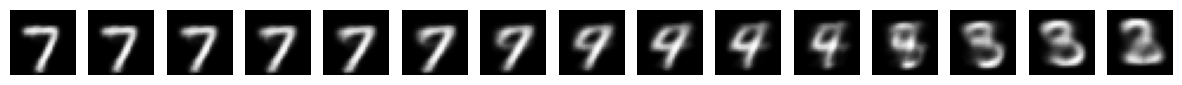

In [55]:
plt.figure(figsize=(15, 2))

for i in range(n_steps):
    ax = plt.subplot(1, n_steps, i + 1)
    plt.imshow(generated[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

La interpolación muestra que el espacio latente es continuo y semánticamente estructurado. Los dígitos evolucionan gradualmente entre clases, lo que confirma que el VAE ha aprendido una representación generativa coherente.